In [63]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import sin, cos, pi
from scipy.integrate import solve_ivp


In [64]:
# Однородный тонкий стержень длины L, масса m, подвес в одном конце.
m = 1.0  # масса (кг)
L = 1.0  # длина стержня (м)
g = 9.81  # ускорение свободного падения (м/с^2)

# Момент инерции стержня относительно конца и расстояние до центра масс
I = (1.0 / 3.0) * m * L**2
d = L / 2.0



In [65]:
# ------------------------ ОДУ ------------------------
# Правые части ОДУ: theta' = omega, omega' = - (b/I) * omega - (m g d / I) * sin(theta)
b = 0.0
def deriv(t, y):
    theta, omega = y
    return np.array([omega, -(b / I) * omega - (m * g * d / I) * np.sin(theta)])


# def rk4_step(fun, t, y, dt, b):
#     k1 = fun(t, y, b)
#     return y + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0

# def integrate(theta0, omega0, b, t_max, dt):
#     # t_span = (0, t_max)
#     # t_eval = np.linspace(*t_span, 500)
#     n = int(np.ceil(t_max / dt)) + 1
#     t = np.linspace(0.0, t_max, n)
#     y = np.zeros((n, 2))
#     y[0] = np.array([theta0, omega0])
#     for i in range(1, n):
#         y[i] = rk4_step(deriv, t[i - 1], y[i - 1], dt, b)
#     return t, y[:, 0], y[:, 1]

def integrate(theta0, omega0, t_max):
    y0 = [theta0, omega0]
    t_span = (0, t_max)
    t_eval = np.linspace(*t_span, 500)
    sol = solve_ivp(deriv, t_span, y0, t_eval=t_eval)
    t = sol.t
    theta = sol.y[0]
    omega = sol.y[1]
    return t, theta, omega


In [66]:
# ------------------------ Энергия ------------------------
# Кинетическая + потенциальная
def energy(theta, omega):
    KE = 0.5 * I * omega**2
    PE = m * g * d * (1 - np.cos(theta))
    return KE + PE




In [67]:
# ------------------------ вычисление периода ------------------------
def find_peaks(t, theta):
    peaks_t = []
    peaks_theta = []
    for i in range(1, len(theta) - 1):
        if theta[i - 1] < theta[i] and theta[i] > theta[i + 1]:
            peaks_t.append(t[i])
            peaks_theta.append(theta[i])
    return np.array(peaks_t), np.array(peaks_theta)


def estimate_period_from_peaks(t, theta):
    peaks_t, peaks_theta = find_peaks(t, theta)
    if len(peaks_t) < 2:
        raise Exception('not enough')
    periods = np.diff(peaks_t)
    return np.mean(periods), peaks_t, peaks_theta




0.0


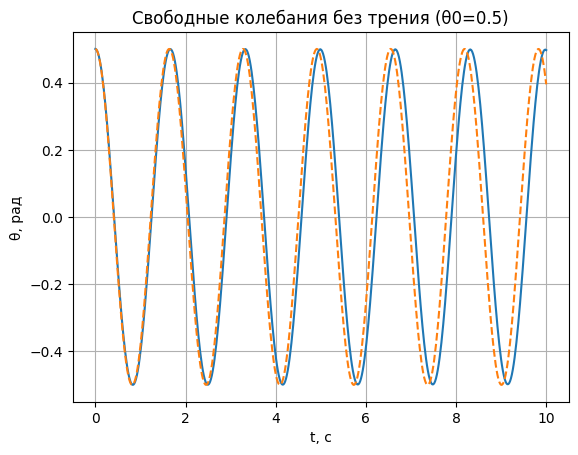

In [68]:

theta_0 = 0.5
omega_0 = 0.0
omega_freq0 = np.sqrt(m * g * d / I)
b = 0.0
t_max = 10.0
t1, th1, om1 = integrate(theta0=theta_0, omega0=omega_0, t_max=t_max)
print(om1[0])
# theta(t) = theta_0 * cos(omega_freq0*t + alpha)
# omega_freq0 = sqrt(mgd/I)

theta_an1 = theta_0 * np.cos(omega_freq0* t1)
omega_an1 = -theta_0 * omega_freq0 * np.sin(omega_freq0 * t1)
plt.figure()
plt.plot(t1, th1)
plt.plot(t1, theta_an1, "--", label="Аналитическое")
plt.xlabel("t, с")
plt.ylabel("θ, рад")
plt.title("Свободные колебания без трения (θ0=0.5)")
plt.grid(True)
plt.show()

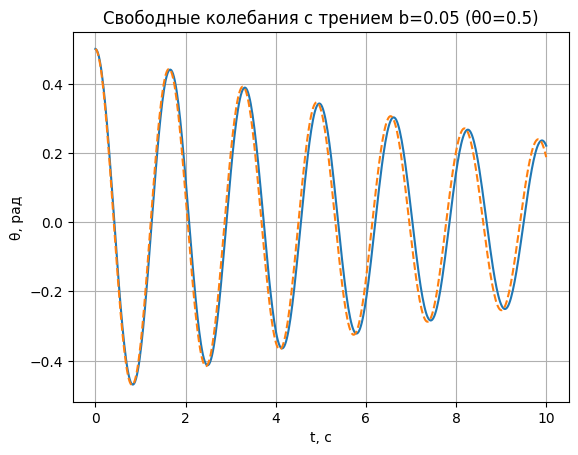

In [69]:
b = 0.05
t2, th2, om2 = integrate(theta0=theta_0, omega0=omega_0, t_max=t_max)

# theta(t) = theta_0 * e ^ (-beta * t) * cos(omega_d * t + alpha)
# omega_d = sqrt( omega_0^2 - beta^2), omega_0 = sqrt( mgd / I)
beta = b / (2 * I)
omega_freq0 = np.sqrt(m * g * d / I)
omega_d = np.sqrt(omega_freq0**2 - beta**2)
theta_an2 = theta_0 * np.exp(-beta * t2) * np.cos(omega_d * t2)
omega_an2 = -theta_0 * np.exp(-beta * t2) * (beta * np.cos(omega_d * t2) + omega_d * np.sin(omega_d * t2))

plt.figure()
plt.plot(t2, th2)
plt.plot(t2, theta_an2, "--", label="Аналитическое")
plt.xlabel("t, с")
plt.ylabel("θ, рад")
plt.title("Свободные колебания с трением b=0.05 (θ0=0.5)")
plt.grid(True)
plt.show()

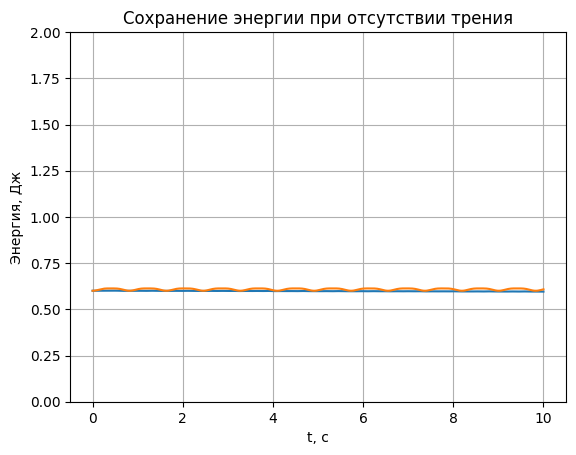

In [70]:
E1 = energy(th1, om1)
E_an1 = energy(theta_an1, omega_an1)
plt.figure()
plt.plot(t1, E1)
plt.plot(t1, E_an1)
plt.xlabel("t, с")
plt.ylabel("Энергия, Дж")
plt.ylim(0.0, 2)
plt.title("Сохранение энергии при отсутствии трения")
plt.grid(True)
plt.show()

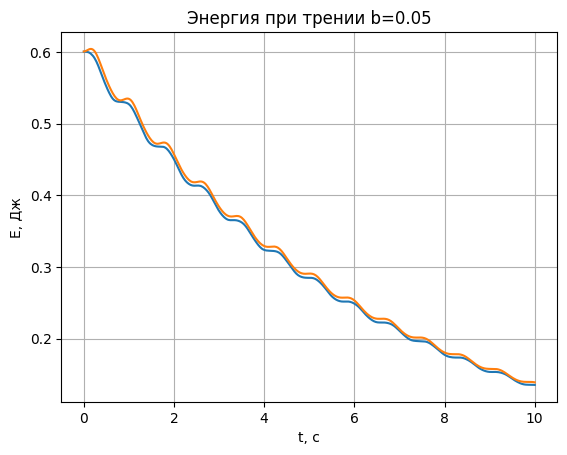

In [71]:
plt.figure()
E_an2 = energy(theta_an2, omega_an2)
plt.plot(t2, energy(th2, om2))
plt.plot(t2, E_an2)
plt.xlabel("t, с")
plt.ylabel("E, Дж")
plt.title("Энергия при трении b=0.05")
plt.grid(True)
plt.show()

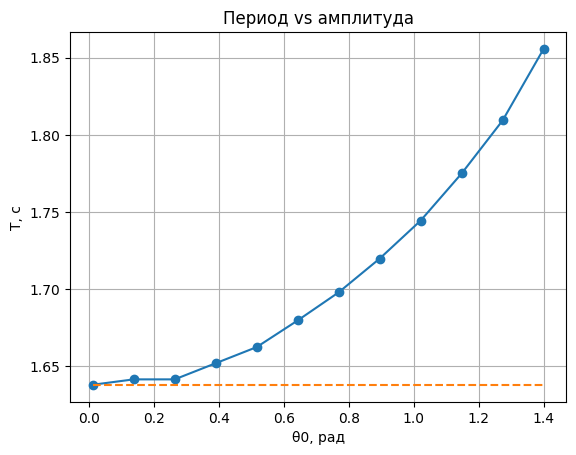

In [ ]:
amps_plot = np.linspace(0.01, 1.4, 12)
T_numeric_list = []
T_theory_full_list = []
T_analytic_list = []
T_small_list = []
b = 0.0
for a in amps_plot:
    t, th, om = integrate(theta0=a, omega0=0.0, t_max=40.0)
    T_est, _, _ = estimate_period_from_peaks(t, th)
    T_numeric_list.append(T_est)
    # theta_0 = 2pi * sqrt (I/mgd)
    theta_0 = 2*pi*np.sqrt(I/(m*g*d))
    T_analytic_list.append(theta_0)

plt.figure()
plt.plot(amps_plot, T_numeric_list, marker="o", linestyle="-")
plt.plot(amps_plot, T_analytic_list, linestyle="--")
plt.xlabel("θ0, рад")
plt.ylabel("T, с")
plt.title("Период vs амплитуда")
plt.grid(True)
plt.show()

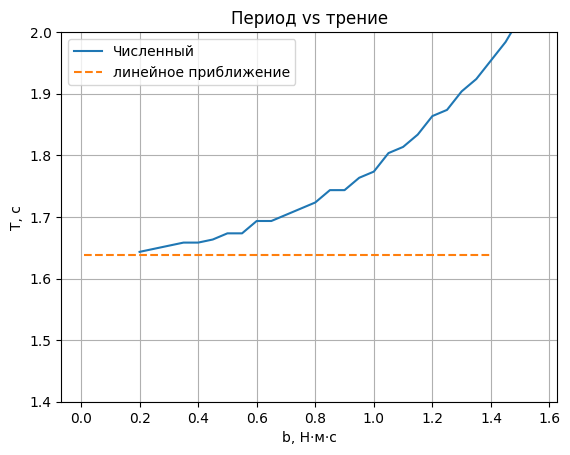

In [ ]:
b_values = [0.01 * i for i in range(20, 160, 5)]
theta0 = 0.5
t_max2 = 5.0
dt2 = 0.001

results_b = []
for b_value in b_values:
    b = b_value
    t, th, om = integrate(theta0=theta0, omega0=0.0, t_max=t_max2)
    T_est, peaks_t, peaks_theta = estimate_period_from_peaks(t, th)
    results_b.append((b, T_est, None, len(peaks_t)))

df_b = pd.DataFrame(
    results_b,
    columns=["b", "T_numeric_s", "T_theory_linear_damped_s", "num_peaks_used"],
)


plt.figure()
plt.plot(df_b["b"], df_b["T_numeric_s"], linestyle="-")
plt.plot(amps_plot, T_analytic_list, linestyle="--")
plt.xlabel("b, Н·м·с")
plt.ylabel("T, с")
plt.ylim(1.4, 2)
plt.title("Период vs трение")
plt.legend(["Численный", "линейное приближение"])
plt.grid(True)
plt.show()